# Laboratorio 7 — Introducción al deep learning con PyTorch

**Natural Language Processing**

En este laboratorio se implementan con PyTorch las ideas vistas en la clase de introducción al deep learning. Cada sección usa un módulo distinto de PyTorch:

| Sección | Módulo principal |
|---|---|
| 1. Redes multicapa | `nn.Module`, `nn.Linear` |
| 2. Funciones de activación | `torch.autograd` |
| 3. Ciclo de entrenamiento | `nn.CrossEntropyLoss`, `torch.optim` |
| 4. Etiquetado POS con RNN | `nn.Embedding`, `nn.LSTM`, `nn.RNN` |
| 9. Conclusiones | — |

Todo corre en CPU.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

# Semilla global para que los resultados sean reproducibles
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

device = torch.device("cpu")
print("PyTorch", torch.__version__)

PyTorch 2.14.1


# 1. Redes multicapa con `nn.Module`

El perceptrón simple no puede resolver XOR porque las dos clases no son linealmente separables: no existe una recta que deje (0,1) y (1,0) de un lado y (0,0) y (1,1) del otro. Aquí se resuelve con un perceptrón multicapa (MLP).

In [2]:
# Datos de XOR: 4 puntos y su etiqueta
X_xor = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y_xor = torch.tensor([[0.], [1.], [1.], [0.]])

### 1.1 Definición del MLP

`MLP` hereda de `nn.Module`: en `__init__` se declaran las capas (sus pesos quedan registrados automáticamente como parámetros) y en `forward` se describe cómo fluye la entrada. La salida es un *logit*; la sigmoide la aplica `nn.BCEWithLogitsLoss` internamente.

In [3]:
class MLP(nn.Module):
    def __init__(self, n_in=2, n_hidden=8, n_out=1, activation=True):
        super().__init__()
        self.hidden = nn.Linear(n_in, n_hidden)
        # Si activation=False la red queda como dos capas lineales apiladas
        self.act = nn.Tanh() if activation else nn.Identity()
        self.out = nn.Linear(n_hidden, n_out)

    def forward(self, x):
        h = self.act(self.hidden(x))
        return self.out(h)


def train_xor(model, epochs=2000, lr=0.05):
    """Entrena sobre XOR y se detiene al llegar a 100% de exactitud (si lo logra)."""
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        logits = model(X_xor)
        loss = loss_fn(logits, y_xor)
        loss.backward()
        optimizer.step()
        acc = ((logits > 0).float() == y_xor).float().mean().item()
        if acc == 1.0 and loss.item() < 0.05:
            break
    return epoch, loss.item(), acc


torch.manual_seed(SEED)
mlp = MLP(activation=True)
epoch, loss, acc = train_xor(mlp)
print(f"MLP con tanh -> época {epoch}, pérdida {loss:.4f}, exactitud {acc:.0%}")

with torch.no_grad():
    probs = torch.sigmoid(mlp(X_xor)).squeeze()
pd.DataFrame({"x1": X_xor[:, 0].int(), "x2": X_xor[:, 1].int(),
              "y real": y_xor.squeeze().int(), "P(y=1)": probs.numpy().round(3),
              "predicción": (probs > 0.5).int()})

MLP con tanh -> época 38, pérdida 0.0483, exactitud 100%


,x1,x2,y real,P(y=1),predicción
0,0,0,0,0.021,0
1,0,1,1,0.935,1
2,1,0,1,0.968,1
3,1,1,0,0.046,0


### 1.2 Frontera de decisión

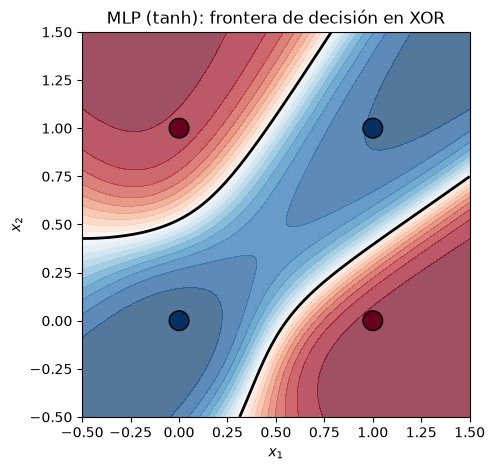

In [4]:
def plot_boundary(model, ax, title):
    xx, yy = torch.meshgrid(torch.linspace(-0.5, 1.5, 300), torch.linspace(-0.5, 1.5, 300), indexing="xy")
    grid = torch.stack([xx.ravel(), yy.ravel()], dim=1)
    with torch.no_grad():
        zz = torch.sigmoid(model(grid)).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=np.linspace(0, 1, 21), cmap="RdBu_r", alpha=0.7)
    ax.contour(xx, yy, zz, levels=[0.5], colors="k", linewidths=2)
    ax.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor.squeeze(), cmap="RdBu_r",
               edgecolors="k", s=200, vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")


fig, ax = plt.subplots(figsize=(5, 5))
plot_boundary(mlp, ax, "MLP (tanh): frontera de decisión en XOR")
plt.show()

### 1.3 La misma red sin función de activación

MLP sin activación -> 5000 épocas, pérdida 0.6931, exactitud 50%
P(y=1) para cada punto: [0.5 0.5 0.5 0.5]


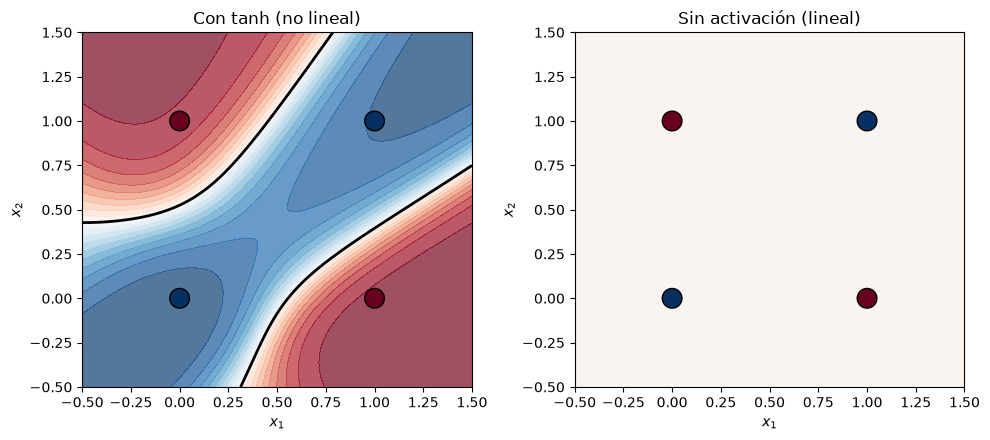

In [5]:
torch.manual_seed(SEED)
mlp_lineal = MLP(activation=False)
epoch, loss, acc = train_xor(mlp_lineal, epochs=5000)
print(f"MLP sin activación -> {epoch} épocas, pérdida {loss:.4f}, exactitud {acc:.0%}")

with torch.no_grad():
    print("P(y=1) para cada punto:", torch.sigmoid(mlp_lineal(X_xor)).squeeze().numpy().round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
plot_boundary(mlp, axes[0], "Con tanh (no lineal)")
plot_boundary(mlp_lineal, axes[1], "Sin activación (lineal)")
plt.tight_layout()
plt.show()

Se puede verificar numéricamente que las dos capas lineales colapsan en una sola: si $h = W_1x + b_1$ y $y = W_2h + b_2$, entonces

$$y = W_2(W_1x + b_1) + b_2 = \underbrace{(W_2W_1)}_{W}\,x + \underbrace{(W_2b_1 + b_2)}_{b}$$

In [6]:
W1, b1 = mlp_lineal.hidden.weight, mlp_lineal.hidden.bias
W2, b2 = mlp_lineal.out.weight, mlp_lineal.out.bias

# Una única capa lineal equivalente
W = W2 @ W1
b = W2 @ b1 + b2
with torch.no_grad():
    salida_red = mlp_lineal(X_xor)
    salida_una_capa = X_xor @ W.T + b
print("W equivalente:", W.detach().numpy().round(4), " b:", b.detach().numpy().round(4))
print("¿Mismas salidas?", torch.allclose(salida_red, salida_una_capa, atol=1e-6))

W equivalente: [[0. 0.]]  b: [0.]
¿Mismas salidas? True


**¿Por qué no resuelve XOR la red sin activación?**

Sin una función no lineal entre las capas, la composición de dos transformaciones afines es otra transformación afín: $W = W_2W_1$ y $b = W_2b_1 + b_2$ (la celda anterior lo confirma, las salidas son idénticas). Por lo tanto, aunque la red tenga 8 neuronas ocultas, su frontera de decisión sigue siendo una recta, exactamente igual que la del perceptrón. Como XOR no es linealmente separable, lo mejor que puede hacer el optimizador es minimizar la pérdida asignando $P(y=1)=0.5$ a los cuatro puntos: la pérdida se estanca en $\ln 2 \approx 0.693$, los pesos efectivos tienden a cero (panel derecho uniforme) y la exactitud queda en 50%.

Con `tanh` la capa oculta deforma el espacio de entrada de manera no lineal; en ese espacio transformado los puntos sí son separables por la capa de salida, y al regresar al plano original la frontera aparece como dos curvas que aíslan las esquinas (0,1) y (1,0).

**Conclusión:** la profundidad sola no basta; lo que da poder expresivo es la combinación de capas **con** activaciones no lineales.

### 1.4 Red de la diapositiva: 3 → 4 → 4 → 2

In [7]:
class RedDiapositiva(nn.Module):
    def __init__(self):
        super().__init__()
        self.capa1 = nn.Linear(3, 4)
        self.capa2 = nn.Linear(4, 4)
        self.salida = nn.Linear(4, 2)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.act(self.capa1(x))
        x = self.act(self.capa2(x))
        return self.salida(x)


red = RedDiapositiva()
total = sum(p.numel() for p in red.parameters())
print(f"Total de parámetros: {total}")
print("Cálculo a mano: (3·4 + 4) + (4·4 + 4) + (4·2 + 2) =", (3*4 + 4) + (4*4 + 4) + (4*2 + 2))

Total de parámetros: 46
Cálculo a mano: (3·4 + 4) + (4·4 + 4) + (4·2 + 2) = 46


In [8]:
pd.DataFrame(
    [(name, tuple(p.shape), p.numel()) for name, p in red.named_parameters()],
    columns=["Parámetro", "Forma", "Elementos"],
)

,Parámetro,Forma,Elementos
0,capa1.weight,"(4, 3)",12
1,capa1.bias,"(4,)",4
2,capa2.weight,"(4, 4)",16
3,capa2.bias,"(4,)",4
4,salida.weight,"(2, 4)",8
5,salida.bias,"(2,)",2


# 2. Funciones de activación

Se calculan sigmoide, tanh y ReLU sobre un mismo tensor y se obtienen sus derivadas con **autograd**, sin escribir las fórmulas a mano.

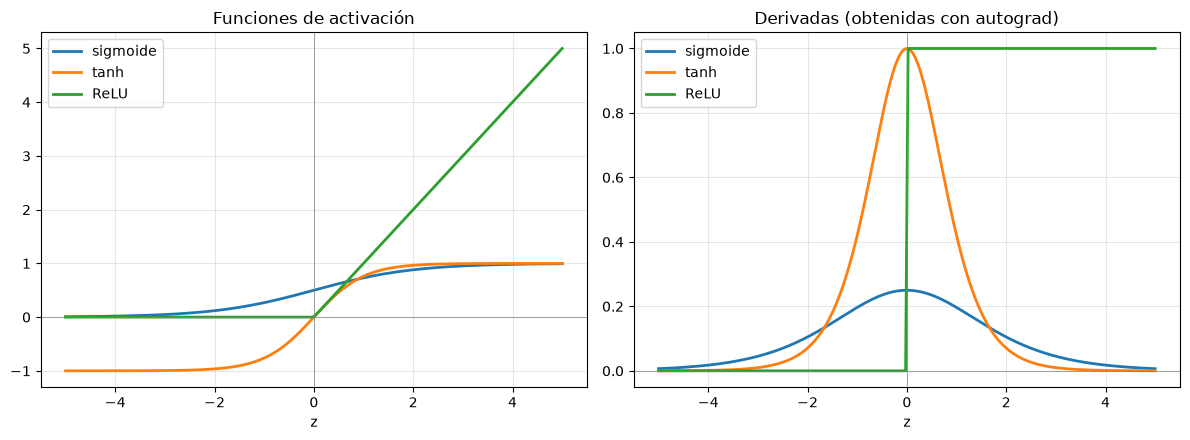

In [9]:
z = torch.linspace(-5, 5, 200, requires_grad=True)

activaciones = {
    "sigmoide": torch.sigmoid,
    "tanh": torch.tanh,
    "ReLU": torch.relu,
}

valores, derivadas = {}, {}
for nombre, f in activaciones.items():
    y = f(z)
    # Como cada salida depende solo de su z_i, el gradiente de la suma es la derivada punto a punto
    (grad,) = torch.autograd.grad(y.sum(), z)
    valores[nombre] = y.detach()
    derivadas[nombre] = grad

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
z_np = z.detach()
for nombre in activaciones:
    ax1.plot(z_np, valores[nombre], label=nombre, lw=2)
    ax2.plot(z_np, derivadas[nombre], label=nombre, lw=2)
ax1.set_title("Funciones de activación")
ax2.set_title("Derivadas (obtenidas con autograd)")
for ax in (ax1, ax2):
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.set_xlabel("z")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Valores puntuales de las derivadas para apoyar el análisis
puntos = [-5.0, -2.5, 0.0, 2.5, 5.0]
idx = [int(torch.argmin((z_np - p).abs())) for p in puntos]
tabla = pd.DataFrame(
    {nombre: [derivadas[nombre][i].item() for i in idx] for nombre in activaciones},
    index=[f"z ≈ {z_np[i]:.2f}" for i in idx],
)
tabla.round(4)

,sigmoide,tanh,ReLU
z ≈ -5.00,0.0066,0.0002,0.0
z ≈ -2.49,0.0709,0.0273,0.0
z ≈ -0.03,0.2500,0.9994,0.0
z ≈ 2.49,0.0709,0.0273,1.0
z ≈ 5.00,0.0066,0.0002,1.0


### Análisis de las derivadas

**¿Dónde se desvanece el gradiente de la sigmoide y de tanh?** En las colas, es decir, cuando $|z|$ es grande (en la práctica desde $|z| \gtrsim 2.5$). Ambas funciones se saturan: la sigmoide se aplana cerca de 0 y 1, y tanh cerca de −1 y 1. En esas regiones la derivada es prácticamente cero (en $z=\pm5$ vale 0.0066 para la sigmoide y 0.0002 para tanh). Además, la derivada de la sigmoide **nunca supera 0.25** (su máximo, en $z=0$). Como en backpropagation los gradientes se multiplican capa por capa, en una red profunda un producto de factores ≤ 0.25 se va encogiendo exponencialmente y las primeras capas casi no aprenden. tanh es algo mejor porque su derivada llega a 1 en el origen y su salida está centrada en cero, pero se satura incluso más rápido que la sigmoide.

**¿Por qué ReLU es la opción por defecto en capas ocultas?**
- Su derivada es exactamente **1 para todo $z>0$**: no se satura en la parte positiva, así que el gradiente pasa sin atenuarse por muchas capas.
- Es muy barata de calcular (un `max(0, z)`), sin exponenciales.
- Produce activaciones dispersas (muchas neuronas en 0), lo que suele funcionar como una forma de regularización.

Su desventaja es que la derivada es 0 para $z<0$: una neurona que siempre recibe entradas negativas deja de actualizarse ("ReLU muerta"). Variantes como Leaky ReLU o GELU atacan ese problema, pero ReLU sigue siendo el punto de partida estándar. La sigmoide se reserva para la salida de clasificación binaria y tanh aparece dentro de las celdas recurrentes (como en la LSTM de la sección 4).

# 3. Pérdida, optimizador y ciclo de entrenamiento

### 3.1 Datos: Iris

In [11]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

iris = load_iris()
X_tr, X_val, y_tr, y_val = train_test_split(
    iris.data, iris.target, test_size=0.2, stratify=iris.target, random_state=SEED
)

# Estandarización con la media y desviación SOLO del conjunto de entrenamiento
media = X_tr.mean(axis=0)
desv = X_tr.std(axis=0)
X_tr = (X_tr - media) / desv
X_val = (X_val - media) / desv

X_tr, X_val = torch.tensor(X_tr, dtype=torch.float32), torch.tensor(X_val, dtype=torch.float32)
y_tr, y_val = torch.tensor(y_tr), torch.tensor(y_val)

print("Entrenamiento:", tuple(X_tr.shape), "| Validación:", tuple(X_val.shape))
print("Clases en entrenamiento:", torch.bincount(y_tr).tolist(), "| en validación:", torch.bincount(y_val).tolist())
print("Media de las features (train) tras estandarizar:", X_tr.mean(0).numpy().round(3))

Entrenamiento: (120, 4) | Validación: (30, 4)
Clases en entrenamiento: [40, 40, 40] | en validación: [10, 10, 10]
Media de las features (train) tras estandarizar: [-0. -0.  0.  0.]


### 3.2 Modelo: MLP 4 → 8 → 3

La última capa devuelve **logits** (sin softmax): una puntuación por especie.

In [12]:
class IrisMLP(nn.Module):
    def __init__(self, n_in=4, n_hidden=8, n_out=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_out),  # logits, sin softmax
        )

    def forward(self, x):
        return self.net(x)


modelo = IrisMLP()
n_params = sum(p.numel() for p in modelo.parameters())
print(f"Parámetros: {n_params}  =  (4·8 + 8) + (8·3 + 3)")

Parámetros: 67  =  (4·8 + 8) + (8·3 + 3)


### 3.3 Ciclo de entrenamiento

Cada época tiene los pasos vistos en clase: `zero_grad` → **forward** → **pérdida** → `loss.backward()` → `optimizer.step()`. Se entrena con el conjunto completo (*full batch*) porque solo hay 120 ejemplos.

In [13]:
def entrenar(optimizador="sgd", lr=0.1, epocas=500):
    torch.manual_seed(SEED)  # misma inicialización para comparar de forma justa
    model = IrisMLP()
    loss_fn = nn.CrossEntropyLoss()
    if optimizador == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.Adam(model.parameters())  # tasa por defecto: 0.001

    hist_train, hist_val = [], []
    for epoca in range(epocas):
        model.train()
        optimizer.zero_grad()          # 0. limpiar gradientes acumulados
        logits = model(X_tr)           # 1. forward
        loss = loss_fn(logits, y_tr)   # 2. pérdida
        loss.backward()                # 3. backward: calcula los gradientes
        optimizer.step()               # 4. actualiza los pesos
        hist_train.append(loss.item())

        model.eval()
        with torch.no_grad():
            hist_val.append(loss_fn(model(X_val), y_val).item())
    return model, hist_train, hist_val


def exactitud(model, X, y):
    model.eval()
    with torch.no_grad():
        pred = model(X).argmax(dim=1)
    return (pred == y).float().mean().item(), pred

**¿Por qué no poner softmax en la última capa?** `nn.CrossEntropyLoss` ya combina internamente `LogSoftmax` + `NLLLoss`, así que espera logits crudos. Si la red aplicara softmax antes, se aplicaría dos veces: las probabilidades se "aplastarían" hacia valores parecidos, la pérdida mínima alcanzable ya no sería cercana a 0 y los gradientes serían mucho más pequeños, por lo que la red aprende más lento y peor. Además, calcular `log(softmax(x))` en un solo paso con el truco *log-sum-exp* es numéricamente estable, mientras que hacer softmax y luego log por separado puede producir `log(0) = -inf` cuando un logit es muy negativo. Para obtener probabilidades en inferencia basta aplicar `torch.softmax` a la salida fuera de la pérdida.

### 3.4 Efecto de la tasa de aprendizaje

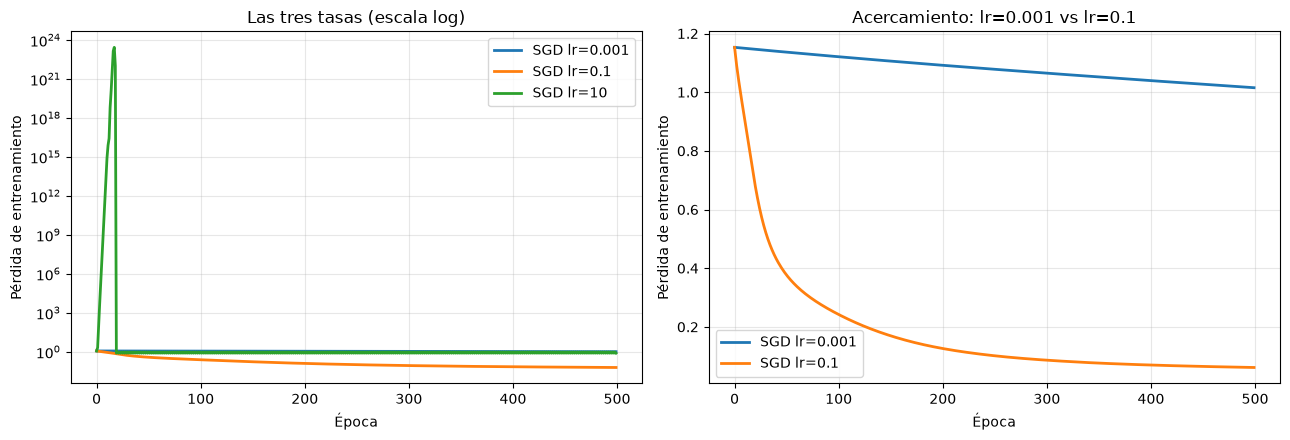

,Configuración,Pérdida inicial,Pérdida final,Pérdida mínima,Exactitud val.
0,SGD lr=0.001,1.1529,1.0153,1.0153,0.7000
1,SGD lr=0.1,1.1529,0.0615,0.0615,0.9667
2,SGD lr=10,1.1529,0.7824,0.7819,0.7000


In [14]:
tasas = [0.001, 0.1, 10]
resultados = {}
for lr in tasas:
    resultados[f"SGD lr={lr}"] = entrenar("sgd", lr=lr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for nombre, (m, h_tr, _) in resultados.items():
    ax1.plot(h_tr, label=nombre, lw=2)
    if "lr=10" not in nombre:
        ax2.plot(h_tr, label=nombre, lw=2)
ax1.set_yscale("log")
ax1.set_title("Las tres tasas (escala log)")
ax2.set_title("Acercamiento: lr=0.001 vs lr=0.1")
for ax in (ax1, ax2):
    ax.set_xlabel("Época")
    ax.set_ylabel("Pérdida de entrenamiento")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

pd.DataFrame(
    [(n, h[0], h[-1], min(h), exactitud(m, X_val, y_val)[0]) for n, (m, h, _) in resultados.items()],
    columns=["Configuración", "Pérdida inicial", "Pérdida final", "Pérdida mínima", "Exactitud val."],
).round(4)

**Comentario sobre las tasas de aprendizaje**

- **lr = 0.001 → aprende demasiado lento.** Tras 500 épocas la pérdida apenas bajó de 1.15 a 1.02 (casi el valor de adivinar al azar, $\ln 3 \approx 1.10$). Los pasos son tan pequeños que necesitaría decenas de miles de épocas.
- **lr = 0.1 → converge.** La pérdida cae rápido en las primeras ~70 épocas y luego sigue bajando suavemente hasta ≈ 0.06, con 96.7% de exactitud en validación.
- **lr = 10 → diverge.** Cada paso sobrepasa el mínimo y cae en una zona con gradiente aún mayor: la pérdida explota hasta ~$10^{23}$ en menos de 20 épocas. Después "cae" de golpe, pero no porque haya aprendido: los pesos quedaron tan grandes que las ReLU de la capa oculta se apagaron (gradiente 0) y la red se estancó en una pérdida de ≈ 0.78, muy por encima de la de lr = 0.1.

### 3.5 SGD vs Adam

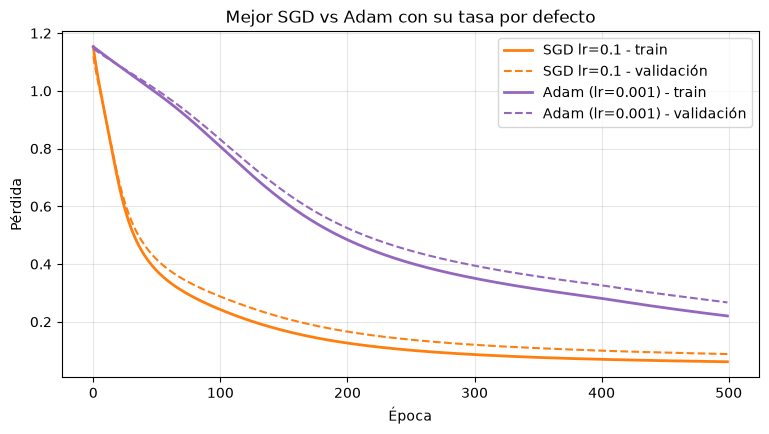

,Optimizador,Pérdida train final,Pérdida val. final,Época en que train < 0.3,Exactitud val.
0,SGD lr=0.1,0.0615,0.0883,73,0.9667
1,Adam (lr=0.001),0.2202,0.2670,370,0.9000


In [15]:
resultados["Adam (lr=0.001)"] = entrenar("adam")
mejor_sgd = "SGD lr=0.1"

fig, ax = plt.subplots(figsize=(9, 4.5))
for nombre, color in [(mejor_sgd, "tab:orange"), ("Adam (lr=0.001)", "tab:purple")]:
    _, h_tr, h_val = resultados[nombre]
    ax.plot(h_tr, color=color, label=f"{nombre} - train", lw=2)
    ax.plot(h_val, "--", color=color, label=f"{nombre} - validación", lw=1.5)
ax.set_xlabel("Época")
ax.set_ylabel("Pérdida")
ax.set_title("Mejor SGD vs Adam con su tasa por defecto")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

def primera_epoca_bajo(h, umbral):
    return next((i for i, v in enumerate(h) if v < umbral), None)

pd.DataFrame(
    [(n, resultados[n][1][-1], resultados[n][2][-1], primera_epoca_bajo(resultados[n][1], 0.3),
      exactitud(resultados[n][0], X_val, y_val)[0]) for n in [mejor_sgd, "Adam (lr=0.001)"]],
    columns=["Optimizador", "Pérdida train final", "Pérdida val. final", "Época en que train < 0.3", "Exactitud val."],
).round(4)

### 3.6 Evaluación del mejor modelo

Mejor modelo: SGD lr=0.1
Exactitud en validación: 96.67% (29/30)


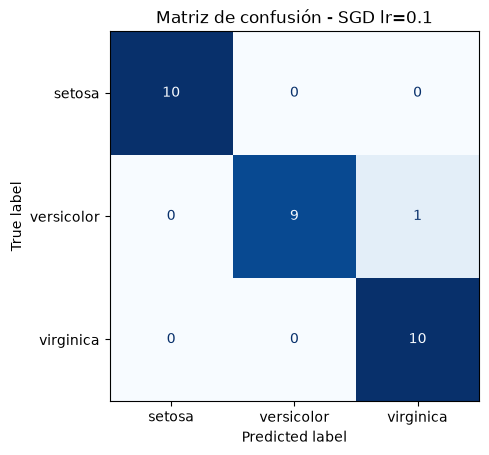

Confusiones por par: {'setosa / versicolor': 0, 'setosa / virginica': 0, 'versicolor / virginica': 1}
Par más confundido: versicolor / virginica


In [16]:
# Mejor modelo = mayor exactitud en validación (en empate, menor pérdida de validación)
candidatos = {n: r for n, r in resultados.items() if "lr=10" not in n}
mejor = max(candidatos, key=lambda n: (exactitud(candidatos[n][0], X_val, y_val)[0], -candidatos[n][2][-1]))
modelo_final = resultados[mejor][0]

modelo_final.eval()
with torch.no_grad():
    pred_val = modelo_final(X_val).argmax(dim=1)
acc_val = (pred_val == y_val).float().mean().item()
print(f"Mejor modelo: {mejor}")
print(f"Exactitud en validación: {acc_val:.2%} ({(pred_val == y_val).sum().item()}/{len(y_val)})")

cm = confusion_matrix(y_val, pred_val)
ConfusionMatrixDisplay(cm, display_labels=iris.target_names).plot(cmap="Blues", colorbar=False)
plt.title(f"Matriz de confusión - {mejor}")
plt.show()

# Par de especies con más confusiones (sumando ambos sentidos)
pares = {(iris.target_names[i], iris.target_names[j]): cm[i, j] + cm[j, i]
         for i in range(3) for j in range(i + 1, 3)}
par = max(pares, key=pares.get)
print("Confusiones por par:", {f"{a} / {b}": int(v) for (a, b), v in pares.items()})
print(f"Par más confundido: {par[0]} / {par[1]}")

**Comparación SGD vs Adam.** Con su tasa por defecto (0.001), Adam es mucho más rápido que SGD con esa **misma** tasa (pérdida 0.22 vs 1.02 a las 500 épocas), porque adapta el paso de cada parámetro usando promedios de los gradientes y de sus cuadrados. Sin embargo, frente al **mejor** SGD (lr = 0.1, que ya fue ajustado a mano) Adam converge más lento en este problema: tarda ~370 épocas en bajar de 0.3 contra ~73 de SGD. La ventaja práctica de Adam es que funciona razonablemente bien "de fábrica" sin buscar la tasa; aquí, con un problema pequeño y una tasa de SGD bien elegida, SGD gana. Si a Adam se le diera una tasa mayor (p. ej. 0.01) alcanzaría a SGD rápidamente.

**Matriz de confusión.** El mejor modelo (SGD, lr = 0.1) obtiene **96.7%** de exactitud en validación (29 de 30), evaluado dentro de `model.eval()` y `torch.no_grad()`. *Setosa* se clasifica perfectamente porque está separada del resto en el tamaño del pétalo; el único error ocurre entre **versicolor y virginica**, las dos especies cuyas medidas se traslapan, por lo que es el par que más confunde el modelo.

# 4. Redes recurrentes para etiquetado POS

### 4.1 Corpus, vocabularios y partición

In [17]:
import nltk
from collections import Counter
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

nltk.download("treebank", quiet=True)
nltk.download("universal_tagset", quiet=True)
from nltk.corpus import treebank

oraciones = list(treebank.tagged_sents(tagset="universal"))
print(f"Oraciones: {len(oraciones)} | Tokens: {sum(len(s) for s in oraciones)}")
print("Ejemplo:", oraciones[0][:8])

# División 80/20 con semilla fija
rng = random.Random(SEED)
indices = list(range(len(oraciones)))
rng.shuffle(indices)
corte = int(0.8 * len(indices))
idx_train, idx_test = indices[:corte], indices[corte:]
train_sents = [oraciones[i] for i in idx_train]
test_sents = [oraciones[i] for i in idx_test]
print(f"Entrenamiento: {len(train_sents)} oraciones | Prueba: {len(test_sents)} oraciones")

Oraciones: 3914 | Tokens: 100676
Ejemplo: [('Pierre', 'NOUN'), ('Vinken', 'NOUN'), (',', '.'), ('61', 'NUM'), ('years', 'NOUN'), ('old', 'ADJ'), (',', '.'), ('will', 'VERB')]
Entrenamiento: 3131 oraciones | Prueba: 783 oraciones


Los vocabularios se construyen **solo con el conjunto de entrenamiento**. Índices especiales:
- `<PAD>` = 0: relleno para igualar longitudes dentro de un batch.
- `<UNK>` = 1: palabra desconocida.

Las palabras se pasan a minúsculas y solo entran al vocabulario las que aparecen al menos 2 veces. Así, las palabras que aparecen una sola vez en entrenamiento se convierten en `<UNK>` y el modelo **sí aprende** un embedding útil para las desconocidas (si todas las palabras de entrenamiento estuvieran en el vocabulario, el vector de `<UNK>` nunca se entrenaría).

In [18]:
PAD, UNK = "<PAD>", "<UNK>"
MIN_FREQ = 2

frecuencias = Counter(w.lower() for s in train_sents for w, _ in s)
itos_palabras = [PAD, UNK] + sorted(w for w, c in frecuencias.items() if c >= MIN_FREQ)
stoi_palabras = {w: i for i, w in enumerate(itos_palabras)}

itos_tags = [PAD] + sorted({t for s in train_sents for _, t in s})
stoi_tags = {t: i for i, t in enumerate(itos_tags)}
PAD_IDX, UNK_IDX, TAG_PAD_IDX = stoi_palabras[PAD], stoi_palabras[UNK], stoi_tags[PAD]

print(f"Vocabulario de palabras: {len(itos_palabras)} (de {len(frecuencias)} formas distintas en train)")
print(f"Etiquetas ({len(itos_tags) - 1} + PAD):", itos_tags[1:])


def codificar_palabras(palabras):
    return torch.tensor([stoi_palabras.get(w.lower(), UNK_IDX) for w in palabras])


def codificar(oracion):
    palabras, tags = zip(*oracion)
    return codificar_palabras(palabras), torch.tensor([stoi_tags[t] for t in tags])


train_data = [codificar(s) for s in train_sents]
test_data = [codificar(s) for s in test_sents]

n_test_tokens = sum(len(s) for s in test_sents)
n_oov = sum((x == UNK_IDX).sum().item() for x, _ in test_data)
print(f"Tokens de prueba fuera del vocabulario (<UNK>): {n_oov} de {n_test_tokens} ({n_oov / n_test_tokens:.1%})")

Vocabulario de palabras: 4838 (de 10108 formas distintas en train)
Etiquetas (12 + PAD): ['.', 'ADJ', 'ADP', 'ADV', 'CONJ', 'DET', 'NOUN', 'NUM', 'PRON', 'PRT', 'VERB', 'X']
Tokens de prueba fuera del vocabulario (<UNK>): 2158 de 19655 (11.0%)


### 4.2 Batches con `pad_sequence`

In [19]:
def collate(batch):
    xs, ys = zip(*batch)
    xs = pad_sequence(xs, batch_first=True, padding_value=PAD_IDX)
    ys = pad_sequence(ys, batch_first=True, padding_value=TAG_PAD_IDX)
    return xs, ys


g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, collate_fn=collate, generator=g)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False, collate_fn=collate)

xb, yb = next(iter(train_loader))
print("Forma de un batch de palabras:", tuple(xb.shape), "| de etiquetas:", tuple(yb.shape))
print("Fila con relleno al final:", xb[(xb == PAD_IDX).sum(1).argmax()][-10:].tolist())

Forma de un batch de palabras: (32, 53) | de etiquetas: (32, 53)
Fila con relleno al final: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


### 4.3 Modelo: `nn.Embedding` → `nn.LSTM` → `nn.Linear`

- **Embedding**: convierte cada índice en un vector denso de 100 dimensiones que se aprende durante el entrenamiento.
- **LSTM** (`batch_first=True`, bidireccional): recorre la oración y produce un estado oculto por token que resume su contexto. Se usa bidireccional para que la etiqueta de cada palabra dependa tanto de las palabras anteriores como de las siguientes (p. ej. en "to book a flight", lo que viene después de *book* ayuda).
- **Linear**: proyecta cada estado oculto a 12 puntuaciones, una por etiqueta.

El mismo módulo acepta `nn.RNN` en lugar de `nn.LSTM` para comparar.

In [20]:
class Etiquetador(nn.Module):
    def __init__(self, vocab_size, n_tags, emb_dim=100, hidden_dim=128, rnn_type="lstm"):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        rnn_cls = nn.LSTM if rnn_type == "lstm" else nn.RNN
        self.rnn = rnn_cls(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(2 * hidden_dim, n_tags)

    def forward(self, x):
        emb = self.embedding(x)       # (batch, largo, emb_dim)
        salida, _ = self.rnn(emb)     # (batch, largo, 2*hidden_dim)
        return self.fc(salida)        # (batch, largo, n_tags)


def evaluar_pos(model, loader):
    """Exactitud por token, sin contar el relleno."""
    model.eval()
    correctos = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            pred = model(xb).argmax(-1)
            mascara = yb != TAG_PAD_IDX
            correctos += (pred[mascara] == yb[mascara]).sum().item()
            total += mascara.sum().item()
    return correctos / total


def entrenar_pos(rnn_type, epocas=10):
    torch.manual_seed(SEED)
    g.manual_seed(SEED)
    model = Etiquetador(len(itos_palabras), len(itos_tags), rnn_type=rnn_type)
    loss_fn = nn.CrossEntropyLoss(ignore_index=TAG_PAD_IDX)  # el relleno no cuenta en la pérdida
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    historial = []
    for epoca in range(1, epocas + 1):
        model.train()
        perdida_total = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits.reshape(-1, logits.size(-1)), yb.reshape(-1))
            loss.backward()
            optimizer.step()
            perdida_total += loss.item()
        acc = evaluar_pos(model, test_loader)
        historial.append((epoca, perdida_total / len(train_loader), acc))
        print(f"[{rnn_type.upper()}] época {epoca:2d} | pérdida {historial[-1][1]:.4f} | exactitud prueba {acc:.4f}")
    return model, historial

### 4.4 Entrenamiento: LSTM

In [21]:
lstm_tagger, hist_lstm = entrenar_pos("lstm")
n_params_lstm = sum(p.numel() for p in lstm_tagger.parameters())
print(f"Parámetros del modelo LSTM: {n_params_lstm:,}")

[LSTM] época  1 | pérdida 1.2899 | exactitud prueba 0.7996


[LSTM] época  2 | pérdida 0.5036 | exactitud prueba 0.8720


[LSTM] época  3 | pérdida 0.3375 | exactitud prueba 0.8990


[LSTM] época  4 | pérdida 0.2460 | exactitud prueba 0.9197


[LSTM] época  5 | pérdida 0.1865 | exactitud prueba 0.9284


[LSTM] época  6 | pérdida 0.1437 | exactitud prueba 0.9335


[LSTM] época  7 | pérdida 0.1117 | exactitud prueba 0.9373


[LSTM] época  8 | pérdida 0.0865 | exactitud prueba 0.9385


[LSTM] época  9 | pérdida 0.0658 | exactitud prueba 0.9409


[LSTM] época 10 | pérdida 0.0498 | exactitud prueba 0.9404
Parámetros del modelo LSTM: 722,661


### 4.5 Reemplazo por `nn.RNN`

In [22]:
rnn_tagger, hist_rnn = entrenar_pos("rnn")
n_params_rnn = sum(p.numel() for p in rnn_tagger.parameters())

[RNN] época  1 | pérdida 1.0630 | exactitud prueba 0.8083


[RNN] época  2 | pérdida 0.5104 | exactitud prueba 0.8590


[RNN] época  3 | pérdida 0.3732 | exactitud prueba 0.8845


[RNN] época  4 | pérdida 0.2892 | exactitud prueba 0.9053


[RNN] época  5 | pérdida 0.2299 | exactitud prueba 0.9193


[RNN] época  6 | pérdida 0.1857 | exactitud prueba 0.9268


[RNN] época  7 | pérdida 0.1515 | exactitud prueba 0.9298


[RNN] época  8 | pérdida 0.1248 | exactitud prueba 0.9342


[RNN] época  9 | pérdida 0.1022 | exactitud prueba 0.9350


[RNN] época 10 | pérdida 0.0847 | exactitud prueba 0.9367


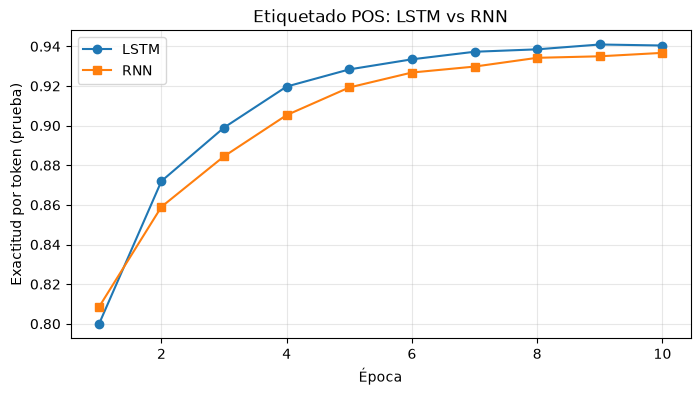

Modelo,Parámetros,Exactitud,Exactitud (palabras conocidas),Exactitud ()
Embedding → LSTM → Linear,"722,661",94.04%,96.35%,75.35%
Embedding → RNN → Linear,"546,021",93.67%,95.87%,75.81%


In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([h[0] for h in hist_lstm], [h[2] for h in hist_lstm], "o-", label="LSTM")
ax.plot([h[0] for h in hist_rnn], [h[2] for h in hist_rnn], "s-", label="RNN")
ax.set_xlabel("Época")
ax.set_ylabel("Exactitud por token (prueba)")
ax.set_title("Etiquetado POS: LSTM vs RNN")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


def exactitud_desglosada(model):
    """Exactitud total, en palabras conocidas y en palabras <UNK>."""
    model.eval()
    res = {"total": [0, 0], "conocidas": [0, 0], "<UNK>": [0, 0]}
    with torch.no_grad():
        for xb, yb in test_loader:
            pred = model(xb).argmax(-1)
            m = yb != TAG_PAD_IDX
            for nombre, mm in [("total", m), ("conocidas", m & (xb != UNK_IDX)), ("<UNK>", m & (xb == UNK_IDX))]:
                res[nombre][0] += (pred[mm] == yb[mm]).sum().item()
                res[nombre][1] += mm.sum().item()
    return {k: c / t for k, (c, t) in res.items()}


tabla_pos = pd.DataFrame(
    [{"Modelo": nombre, "Parámetros": n, **exactitud_desglosada(m)}
     for nombre, m, n in [("Embedding → LSTM → Linear", lstm_tagger, n_params_lstm),
                          ("Embedding → RNN → Linear", rnn_tagger, n_params_rnn)]]
).rename(columns={"total": "Exactitud", "conocidas": "Exactitud (palabras conocidas)", "<UNK>": "Exactitud (<UNK>)"})
tabla_pos.style.format({"Parámetros": "{:,}", "Exactitud": "{:.2%}",
                        "Exactitud (palabras conocidas)": "{:.2%}", "Exactitud (<UNK>)": "{:.2%}"}).hide(axis="index")

**LSTM vs RNN.** Tras 10 épocas la LSTM alcanza **94.0%** de exactitud por token y la RNN simple **93.7%**. La LSTM gana, aunque por poco, y además converge a una pérdida de entrenamiento menor. La diferencia es pequeña porque (1) las oraciones son relativamente cortas, (2) ambas redes son bidireccionales, y (3) para POS la mayor parte de la información está en la propia palabra y en sus vecinas inmediatas, justo el rango en el que una RNN simple todavía no sufre de gradiente desvaneciente. Las compuertas de la LSTM (olvido, entrada y salida) importan más cuando hay dependencias largas. En ambos modelos el punto débil son las palabras desconocidas: ~96% de exactitud en palabras del vocabulario contra ~75% en `<UNK>`, porque para estas el modelo solo cuenta con el contexto.

### 4.6 Palabras ambiguas en oraciones propias

Se usa el mejor modelo (LSTM) para etiquetar oraciones donde la misma palabra cumple funciones distintas según el contexto.

In [24]:
mejor_tagger = lstm_tagger


def etiquetar(oracion):
    palabras = oracion.split()
    mejor_tagger.eval()
    with torch.no_grad():
        pred = mejor_tagger(codificar_palabras(palabras).unsqueeze(0)).argmax(-1).squeeze(0)
    return [(w, itos_tags[t]) for w, t in zip(palabras, pred.tolist())]


casos = [
    ("I want to book a flight to Boston .", "book", "VERB"),
    ("She read a good book about history .", "book", "NOUN"),
    ("They run five miles every morning .", "run", "VERB"),
    ("The company had a long run of profits .", "run", "NOUN"),
    ("Investors will record the sales in March .", "record", "VERB"),
    ("The firm reported a record profit .", "record", "ADJ/NOUN"),
    ("The plant will close next year .", "close", "VERB"),
    ("The vote was very close .", "close", "ADJ"),
    ("Last year the market saw a sharp rise .", "rise", "NOUN"),
    ("Analysts expect rates to rise .", "rise", "VERB"),
]

# Cómo aparece cada palabra en el conjunto de entrenamiento
tags_en_train = {}
for s_ in train_sents:
    for w, t in s_:
        tags_en_train.setdefault(w.lower(), Counter())[t] += 1

filas = []
for oracion, palabra, esperado in casos:
    etiquetas = etiquetar(oracion)
    asignada = next(t for w, t in etiquetas if w == palabra)
    filas.append({"Oración": oracion, "Palabra": palabra,
                  "Etiquetas en train": dict(tags_en_train.get(palabra, {})),
                  "Esperada": esperado, "LSTM": asignada,
                  "Correcta": asignada in esperado.split("/")})
tabla_ambiguas = pd.DataFrame(filas)
tabla_ambiguas

,Oración,Palabra,Etiquetas en train,Esperada,LSTM,Correcta
0,I want to book a flight to Boston .,book,{'NOUN': 6},VERB,VERB,True
1,She read a good book about history .,book,{'NOUN': 6},NOUN,NOUN,True
2,They run five miles every morning .,run,"{'VERB': 12, 'NOUN': 2}",VERB,VERB,True
3,The company had a long run of profits .,run,"{'VERB': 12, 'NOUN': 2}",NOUN,NOUN,True
4,Investors will record the sales in March .,record,"{'NOUN': 20, 'ADJ': 2, 'VERB': 3}",VERB,VERB,True
5,The firm reported a record profit .,record,"{'NOUN': 20, 'ADJ': 2, 'VERB': 3}",ADJ/NOUN,NOUN,True
6,The plant will close next year .,close,"{'ADJ': 8, 'NOUN': 8, 'VERB': 6, 'ADV': 2}",VERB,VERB,True
7,The vote was very close .,close,"{'ADJ': 8, 'NOUN': 8, 'VERB': 6, 'ADV': 2}",ADJ,ADJ,True
8,Last year the market saw a sharp rise .,rise,"{'VERB': 8, 'NOUN': 7}",NOUN,NOUN,True
9,Analysts expect rates to rise .,rise,"{'VERB': 8, 'NOUN': 7}",VERB,VERB,True


In [25]:
for oracion, *_ in casos[:4]:
    print("  ".join(f"{w}/{t}" for w, t in etiquetar(oracion)))

I/PRON  want/VERB  to/PRT  book/VERB  a/DET  flight/NOUN  to/PRT  Boston/NOUN  ./.
She/PRON  read/VERB  a/DET  good/ADJ  book/NOUN  about/ADP  history/NOUN  ./.
They/PRON  run/VERB  five/ADV  miles/NOUN  every/DET  morning/NOUN  ./.
The/DET  company/NOUN  had/VERB  a/DET  long/ADJ  run/NOUN  of/ADP  profits/NOUN  ./.


**¿Resuelve el contexto la ambigüedad?** Sí. El modelo etiqueta correctamente los 10 casos, y el más revelador es *book*: en el conjunto de entrenamiento aparece **solo como sustantivo** (6 veces), y aun así en "I want **to book** a flight" la LSTM lo etiqueta como `VERB`. Eso no puede venir de memorizar la etiqueta más frecuente de la palabra; viene del contexto: el estado oculto que llega a *book* ya "sabe" que antes hay *to* tras un verbo y que después viene un determinante (*a flight*), patrón típico de un infinitivo. Es exactamente la idea del ejemplo de "vino" de la clase (verbo en "él vino ayer" y sustantivo en "tomó vino"): el embedding de la palabra es el mismo en ambas oraciones, pero la representación contextual que produce la LSTM es distinta y eso es lo que usa la capa lineal para decidir. Lo mismo ocurre con *run*, *record*, *close* y *rise*.

El modelo no es perfecto: en las oraciones de arriba etiqueta *five* como `ADV` (debería ser `NUM`) y el *to* de "to Boston" como `PRT` (debería ser `ADP`), errores razonables para un modelo entrenado con solo ~3,100 oraciones.

### 4.7 Comparación con el tagger de spaCy (Laboratorio 6)

En el Laboratorio 6 se usó `en_core_web_sm` de spaCy. Para comparar de forma justa se evalúa sobre **las mismas oraciones de prueba**, dándole a spaCy los tokens del treebank ya separados (para no mezclar errores de tokenización) y convirtiendo su etiqueta fina de Penn Treebank (`token.tag_`) al tagset universal con el mismo mapeo que usa NLTK.

El treebank contiene además **elementos vacíos** (trazas sintácticas como `*-1`, `*T*-2` o `0`, etiquetadas como `-NONE-` → `X`) que no son palabras reales. spaCy nunca los ve, así que en esta comparación se excluyen de ambos modelos.

In [26]:
import spacy
from spacy.tokens import Doc
from nltk.tag.mapping import map_tag

nlp = spacy.load("en_core_web_sm")

# Etiquetas originales de Penn Treebank para identificar los elementos vacíos (-NONE-)
oraciones_ptb = list(treebank.tagged_sents())
test_ptb = [oraciones_ptb[i] for i in idx_test]

EXTRA = {"HYPH": ".", "NFP": ".", "_SP": "."}  # etiquetas de spaCy que no están en el mapeo de NLTK


def ptb_a_universal(tag):
    return EXTRA.get(tag) or map_tag("en-ptb", "universal", tag)


aciertos = {"spaCy": 0, "LSTM": 0, "RNN": 0}
total = 0
for sent_univ, sent_ptb, (x, y) in zip(test_sents, test_ptb, test_data):
    reales = [i for i, (_, tag) in enumerate(sent_ptb) if tag != "-NONE-"]
    palabras = [sent_univ[i][0] for i in reales]
    oro = [sent_univ[i][1] for i in reales]

    doc = nlp(Doc(nlp.vocab, words=palabras))
    pred_spacy = [ptb_a_universal(t.tag_) for t in doc]

    with torch.no_grad():
        pred_lstm = lstm_tagger(x.unsqueeze(0)).argmax(-1).squeeze(0)
        pred_rnn = rnn_tagger(x.unsqueeze(0)).argmax(-1).squeeze(0)

    aciertos["spaCy"] += sum(p == g for p, g in zip(pred_spacy, oro))
    aciertos["LSTM"] += sum(pred_lstm[i].item() == y[i].item() for i in reales)
    aciertos["RNN"] += sum(pred_rnn[i].item() == y[i].item() for i in reales)
    total += len(reales)

print(f"Tokens evaluados (sin elementos vacíos): {total}")
tabla_comp = pd.DataFrame(
    [("spaCy en_core_web_sm (Lab 6)", aciertos["spaCy"] / total),
     ("LSTM bidireccional (este lab)", aciertos["LSTM"] / total),
     ("RNN bidireccional (este lab)", aciertos["RNN"] / total)],
    columns=["Etiquetador", "Exactitud (sin trazas)"],
)
tabla_comp.style.format({"Exactitud (sin trazas)": "{:.2%}"}).hide(axis="index")

Tokens evaluados (sin elementos vacíos): 18396


Etiquetador,Exactitud (sin trazas)
spaCy en_core_web_sm (Lab 6),96.72%
LSTM bidireccional (este lab),93.73%
RNN bidireccional (este lab),93.30%


**¿A qué se debe la diferencia?** spaCy obtiene **96.7%** frente a **93.7%** de nuestra LSTM, unos 3 puntos más. (En el Lab 6 se había observado ~98% de coincidencia con una anotación manual de 116 tokens; sobre el treebank completo la cifra es un poco menor, como es de esperar con una muestra mucho mayor.) Se atribuye a:

1. **Tamaño del corpus.** Nuestra LSTM se entrenó con ~3,100 oraciones (~80 mil tokens), la muestra del Penn Treebank incluida en NLTK. `en_core_web_sm` se entrenó con OntoNotes 5, del orden de millones de tokens de noticias, conversaciones, web, etc. Con tan pocos datos el 11% de los tokens de prueba es `<UNK>` para nuestro modelo, y ahí su exactitud cae a ~75%. Hay que notar además que OntoNotes incluye texto del Wall Street Journal, así que spaCy probablemente vio oraciones de este mismo dominio (o incluso estas mismas) durante su entrenamiento, lo que favorece su resultado.
2. **Embeddings.** Nuestros embeddings parten de valores aleatorios y solo aprenden de 4,838 palabras; una palabra nueva colapsa en un único vector `<UNK>`. spaCy representa cada token con *hash embeddings* de la forma en minúsculas, el prefijo, el sufijo y la "forma" de la palabra (mayúsculas, dígitos), así que una palabra nunca vista como *refinancing* todavía aporta información por su sufijo *-ing*.
3. **Arquitectura.** spaCy usa un codificador convolucional (CNN con ventanas sobre el contexto) entrenado en múltiples tareas, mientras que el nuestro es una sola capa LSTM entrenada 10 épocas sin regularización ni ajuste de hiperparámetros. La diferencia no se debe a que una LSTM sea inferior: con más datos, embeddings preentrenados y features de caracteres, los etiquetadores BiLSTM alcanzan ~97% en el Penn Treebank.

# 9. Conclusiones: del perceptrón a la atención

### ¿Por qué XOR fue tan importante y qué permitió resolverlo?

En 1969 Minsky y Papert demostraron en *Perceptrons* que un perceptrón de una sola capa no puede representar funciones que no sean linealmente separables, y XOR, una función lógica elemental, es el ejemplo más simple. Como en ese momento no se sabía entrenar redes con capas ocultas, el resultado se interpretó como un límite de las redes neuronales en general, contribuyó al recorte de financiamiento y al llamado "invierno de la IA", y el campo quedó prácticamente congelado hasta que la retropropagación (Rumelhart, Hinton y Williams, 1986) permitió entrenar redes multicapa. La sección 1 muestra cuál es el ingrediente exacto: **se necesitan ambos, capas ocultas y activación no lineal**. Una capa oculta sin activación colapsa en una sola transformación lineal ($W = W_2W_1$) y se queda en 50% de exactitud, igual que el perceptrón; y una activación no lineal sin capa oculta solo deforma la salida, pero la frontera de decisión sigue siendo una recta. Solo la combinación permite que la capa oculta transforme el espacio de entrada en uno donde las clases sí son separables, que es lo que hizo la red con `tanh` al llegar a 100% en 38 épocas.

### One-hot / TF-IDF / bag-of-words vs embeddings densos

En laboratorios anteriores los textos se representaron con bag-of-words y TF-IDF: vectores **dispersos** de dimensión igual al tamaño del vocabulario, donde cada palabra es una dimensión independiente. La representación one-hot de una palabra es el caso extremo: un vector con un solo 1. En esos espacios todas las palabras son ortogonales entre sí; "stock" está tan lejos de "share" como de "banana", así que el modelo no puede generalizar lo aprendido de una palabra a otra parecida, y el número de parámetros crece con el vocabulario.

Un `nn.Embedding` es matemáticamente una capa lineal aplicada a ese one-hot (multiplicar el one-hot por la matriz $E$ equivale a seleccionar una fila), pero su salida es un vector **denso** y de dimensión baja (100 en la sección 4) que se aprende para la tarea. Lo que gana el modelo:
- **Similitud:** palabras que se usan en contextos parecidos terminan con vectores cercanos, por lo que lo aprendido con una se transfiere a las demás.
- **Eficiencia:** pocas dimensiones continuas en vez de decenas de miles casi siempre en cero.
- **Composición con el contexto:** una red recurrente puede combinar estos vectores en orden, algo que bag-of-words pierde por completo al ignorar la posición.

**Relación con OOV:** ni los vectores dispersos ni los embeddings por palabra resuelven por sí solos el problema de vocabulario fuera de dominio. En bag-of-words/TF-IDF una palabra nueva simplemente no tiene columna y se descarta; en nuestro modelo se mapea a `<UNK>` y pierde su identidad. La diferencia es que los embeddings densos abren la puerta a soluciones: como el significado vive en un espacio continuo, se puede **construir** un vector razonable para una palabra nueva a partir de sus partes (subpalabras, caracteres) o importarlo de embeddings preentrenados en un corpus mucho más grande (word2vec, GloVe, fastText), algo imposible con dimensiones one-hot independientes.

### ¿Cómo maneja nuestra LSTM las palabras desconocidas y cómo mejorarlo?

Toda palabra que no está en el vocabulario de entrenamiento (o que apareció solo una vez) se reemplaza por el índice `<UNK>`, que tiene un único embedding compartido. Como las palabras de frecuencia 1 se mapearon a `<UNK>` durante el entrenamiento, ese vector sí se aprendió y representa algo así como "palabra rara", que en el treebank suele ser sustantivo, nombre propio o adjetivo. A partir de ahí el modelo depende **solo del contexto**: eso explica que acierte ~75% de los `<UNK>` (bastante mejor que adivinar), pero muy por debajo del ~96% de las palabras conocidas. El problema es que *refinancing*, *Vinken* y *42.5* reciben exactamente el mismo vector.

Propuestas de mejora (de menor a mayor esfuerzo):
1. **Varias clases de `<UNK>` según la forma**: `<UNK-ing>`, `<UNK-ed>`, `<UNK-ly>`, `<UNK-Mayúscula>`, `<UNK-número>`, etc. Es barato y ataca justo los errores más comunes.
2. **Embeddings a nivel de caracteres**: una pequeña CNN o LSTM sobre los caracteres de cada palabra cuyo vector se concatena con el embedding de palabra. Así una palabra nueva nunca es totalmente desconocida porque su morfología (sufijos, mayúsculas, dígitos) aporta información.
3. **Embeddings preentrenados** con `gensim` (word2vec o, mejor, fastText, que usa n-gramas de caracteres y puede generar un vector para cualquier palabra) entrenados en un corpus grande, para inicializar `nn.Embedding` y reducir drásticamente la tasa de OOV.
4. **Tokenización en subpalabras** (BPE/WordPiece), la solución que usan los modelos basados en atención: ninguna palabra es OOV porque siempre se puede descomponer en piezas conocidas.